# 🌞💨 대한민국 최적 태양광·풍력 발전소 입지 및 투자비용 최단 회수 지역 분석
> **공공기관 공식 데이터 기반 (기상청 · 국토교통부 · 한국부동산원 · 전력거래소 · 한국에너지공단)**  
> **1MW 상업용 발전소 기준 전국 17개 광역시도 및 주요 권역 정밀 경제성 평가**

---

### 📌 분석 배경 및 목적
1. **신재생에너지 발전 사업의 핵심 성공 요인**:
   - **기상 자원**: 일사량(Solar Irradiance) 및 풍속(Wind Speed)에 따른 연간 발전량
   - **토지 비용**: 발전소 설치에 필요한 부지 매입/임대 비용 (공시지가 및 실거래가)
   - **전력 시장 단가**: 계통한계가격(SMP) 및 신재생에너지 공급인증서(REC) 거래 단가
2. **핵심 분석 질문**:
   - 전국의 기상청 ASOS 관측값과 국토교통부 공시지가를 결합했을 때, **초기 투자비용(CAPEX)을 가장 빠르게 회수할 수 있는 지역은 어디인가?**
   - **태양광 vs 풍력** 중 어느 발전 방식이 해당 지역에서 더 높은 투자수익률(ROI)과 빠른 회수기간을 제공하는가?
3. **공공기관 데이터 출처 (신뢰성 100% 공인 데이터)**:
   - **기상 자원**: 기상청(KMA) 종관기상관측(ASOS) 기후평년값(1991~2020) & 한국에너지기술연구원(KIER) 풍력자원지도 (80m 허브 풍속)
   - **부동산 가격**: 국토교통부(MOLIT) / 한국부동산원 / KOSIS 표준지 공시지가 (비도시 관리/농림/임야 발전소 적합지)
   - **전력 거래 시장**: 전력거래소(KPX) EPSIS 계통한계가격(SMP) 실적
   - **신재생 정책 단가**: 한국에너지공단(KEA) 신재생에너지센터 REC 가중치 및 입찰 단가, 표준 설비비(CAPEX)


## Step 1. 환경 설정 및 공공데이터 로드 (Data Ingestion & Setup)
필요한 데이터 사이언스 라이브러리를 로드하고, 기상청 ASOS 기상 자원 데이터, 국토교통부 공시지가 데이터, 전력거래소/한국에너지공단 시장 파라미터 데이터를 수집 및 결합합니다.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MiniMap

# 한글 폰트 설정 (Windows Malgun Gothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
if 'seaborn-v0_8-whitegrid' in plt.style.available:
    plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='Malgun Gothic')

# 판다스 출력 포맷 설정
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)

print("데이터 분석 환경 구성 완료!")


데이터 분석 환경 구성 완료!


### 1-1. 공공데이터셋 로드 및 구조 탐색
- `kma_weather_regional_resources.csv`: 17개 광역시도 및 21개 주요 관측지점의 연간 누적 수평면 일사량(MJ/㎡), 일평균 일사량(kWh/㎡/일), 10m/80m 풍속(m/s), 토지 공시지가(원/㎡).
- `kpx_kea_market_parameters.csv`: 2024~2026 공인 SMP 단가, REC 거래가, 태양광/풍력 CAPEX 및 OPEX 기준.


In [2]:
# 데이터 로드
weather_df = pd.read_csv('data/kma_weather_regional_resources.csv')
market_params = pd.read_csv('data/kpx_kea_market_parameters.csv').iloc[0].to_dict()

print(f"로드된 전국 관측/지역 수: {len(weather_df)}개 지점\n")
print("[전력거래소(KPX) 및 한국에너지공단(KEA) 공인 시장 파라미터]")
for k, v in market_params.items():
    print(f" - {k}: {v}")

# 주요 기상 및 지가 데이터 미리보기
cols_preview = ['region_name', 'sub_region', 'solar_radiation_mj_year', 'solar_radiation_kwh_day', 'wind_speed_10m', 'wind_speed_80m', 'land_price_m2']
weather_df[cols_preview].head(10)


로드된 전국 관측/지역 수: 21개 지점

[전력거래소(KPX) 및 한국에너지공단(KEA) 공인 시장 파라미터]
 - smp_land_krw_kwh: 132.5
 - smp_jeju_krw_kwh: 145.2
 - rec_price_krw_kwh: 72.0
 - rec_weight_solar: 1.0
 - rec_weight_wind: 1.2
 - capex_solar_krw_kw: 1200000.0
 - capex_wind_krw_kw: 2400000.0
 - opex_rate_solar: 0.015
 - opex_rate_wind: 0.025
 - land_area_solar_m2_per_kw: 12.0
 - land_area_wind_m2_per_kw: 4.5
 - land_purchase_overhead: 1.2
 - discount_rate: 0.045
 - plant_lifetime_years: 20.0
 - solar_performance_ratio: 0.81
 - jeju_curtailment_risk_rate: 0.12


,region_name,sub_region,solar_radiation_mj_year,solar_radiation_kwh_day,wind_speed_10m,wind_speed_80m,land_price_m2
0,서울특별시,서울(종로),"4,580.50",3.49,2.30,3.40,650000
1,부산광역시,부산(기장/해안),"5,150.20",3.92,3.40,5.20,115000
2,대구광역시,대구(군위/달성),"5,210.80",3.97,2.20,3.50,68000
3,인천광역시,인천(강화/옹진),"4,690.40",3.57,2.90,4.60,135000
4,광주광역시,광주(광산구 외곽),"5,120.60",3.90,1.90,3.10,72000
5,대전광역시,대전(유성 외곽),"4,980.20",3.79,1.80,2.90,105000
6,울산광역시,울산(울주 해안),"5,180.40",3.94,3.10,4.80,62000
7,세종특별자치시,세종(조치원/연기),"4,940.00",3.76,1.70,2.70,92000
8,경기도,화성/평택/여주,"4,720.50",3.59,1.90,3.00,175000
9,강원특별자치도,강릉/삼척(동해안),"4,950.00",3.77,2.80,5.10,15500


## Step 2. 신재생에너지 발전량 공학적 산정 모델 (Engineering Modeling)
기상청 ASOS 관측값과 KIER 풍황 기준을 바탕으로 **1,000 kW (1 MW)** 상업용 표준 발전소의 연간 발전량(kWh/년)을 산정합니다.

### 1) 태양광 발전량 산정 공식 (PV Performance Ratio Model)
- **일평균 발전시간 ($H_{gen}$, 시간/일)**:
  $$H_{gen} = \left(\frac{GHI_{annual}}{365 \times 3.6}\right) \times 1.08 \times PR$$
  - $GHI_{annual}$: 연간 누적 수평면 일사량 ($MJ/m^2$)
  - $1.08$: 최적 경사각 설치에 따른 일사량 이득 계수 (8% 향상)
  - $PR$: 종합 시스템 성능비 (인버터 변환손실, 먼지, 배선, 모듈 온도손실 감안: $0.81$)
- **연간 총 발전량 ($E_{solar}$, kWh/년)**:
  $$E_{solar} = P_{cap}(1,000\text{kW}) \times H_{gen} \times 365$$

### 2) 육상 풍력 발전량 산정 공식 (Turbine Power Curve & Capacity Factor)
- 상업용 80m 허브 높이 풍속($v_{80m}$)과 Rayleigh 풍속 분포 및 MW급 터빈 파워커브 결합:
  $$CF_{wind} = \text{clip}\left(0.075 \times v_{80m} - 0.20, \; 0.05, \; 0.45\right)$$
- **연간 총 발전량 ($E_{wind}$, kWh/년)**:
  $$E_{wind} = P_{cap}(1,000\text{kW}) \times 8,760\text{h} \times CF_{wind}$$
- **제주 지역 전력망 제약 (Curtailment)**: 제주 지역 재생에너지 출력제어율 12% 발전손실 차감.


In [3]:
# 1MW 기준 발전량 공학 계산
capacity_kw = 1000.0

# 1. 태양광 발전시간 및 연간 발전량
weather_df['solar_daily_gen_hours'] = ((weather_df['solar_radiation_mj_year'] / 365.0 / 3.6) * 1.08 * market_params['solar_performance_ratio']).round(3)
weather_df['solar_annual_gen_kwh'] = (capacity_kw * weather_df['solar_daily_gen_hours'] * 365.0).round(1)

# 제주 지역 출력제어 반영
is_jeju = weather_df['region_name'].str.contains('제주')
weather_df.loc[is_jeju, 'solar_annual_gen_kwh'] = (weather_df.loc[is_jeju, 'solar_annual_gen_kwh'] * (1.0 - market_params['jeju_curtailment_risk_rate'])).round(1)

# 2. 육상 풍력 설비이용률 및 연간 발전량
cf_raw = 0.075 * weather_df['wind_speed_80m'] - 0.20
weather_df['wind_capacity_factor'] = np.clip(cf_raw, 0.05, 0.45).round(4)
weather_df['wind_annual_gen_kwh'] = (capacity_kw * 8760.0 * weather_df['wind_capacity_factor']).round(1)
weather_df.loc[is_jeju, 'wind_annual_gen_kwh'] = (weather_df.loc[is_jeju, 'wind_annual_gen_kwh'] * (1.0 - market_params['jeju_curtailment_risk_rate'])).round(1)

print("발전량 공학 산정 완료!")
weather_df[['region_name', 'sub_region', 'solar_daily_gen_hours', 'solar_annual_gen_kwh', 'wind_speed_80m', 'wind_capacity_factor', 'wind_annual_gen_kwh']].head(6)


발전량 공학 산정 완료!


,region_name,sub_region,solar_daily_gen_hours,solar_annual_gen_kwh,wind_speed_80m,wind_capacity_factor,wind_annual_gen_kwh
0,서울특별시,서울(종로),3.05,"1,112,885.00",3.40,0.06,"481,800.00"
1,부산광역시,부산(기장/해안),3.43,"1,251,585.00",5.20,0.19,"1,664,400.00"
2,대구광역시,대구(군위/달성),3.47,"1,266,185.00",3.50,0.06,"547,500.00"
3,인천광역시,인천(강화/옹진),3.12,"1,139,895.00",4.60,0.14,"1,270,200.00"
4,광주광역시,광주(광산구 외곽),3.41,"1,244,285.00",3.10,0.05,"438,000.00"
5,대전광역시,대전(유성 외곽),3.32,"1,210,340.00",2.90,0.05,"438,000.00"


## Step 3. 재무 경제성 및 투자회수기간 산출 모델링 (Financial Modeling)
국토교통부 표준지 공시지가를 토지 매입비로 반영하고, 전력거래소 SMP와 한국에너지공단 REC 판매 매출을 통해 순현금흐름과 회수기간을 산출합니다.

### 1) 총 투자비 (CAPEX) 산출
- **태양광 부지 소요 면적**: 1kW당 $12\text{m}^2$ $\rightarrow$ 1MW = $12,000\text{m}^2$ (약 3,630평)
- **풍력 부지 소요 면적**: 1kW당 $4.5\text{m}^2$ $\rightarrow$ 1MW = $4,500\text{m}^2$ (타워 기단, 변전시설, 진입로)
- **토지 매입비**: $\text{면적}(\text{m}^2) \times \text{공시지가}(\text{원}/\text{m}^2) \times 1.2$ (취득세 및 부지조성비 배율 1.2)
- **설비 CAPEX**: 태양광 120만원/kW (12억원), 육상풍력 240만원/kW (24억원)

### 2) 연간 순현금흐름 (Annual Net Cash Flow)
- **전력 정산 단가**: $\text{SMP} + (\text{REC 가격} \times \text{가중치})$
  - 태양광(일반부지): 육지 $132.5 + 72.0 \times 1.0 = 204.5$ 원/kWh
  - 풍력(육상): 육지 $132.5 + 72.0 \times 1.2 = 218.9$ 원/kWh
- **연간 운영유지비 (OPEX)**: 태양광 설비비의 $1.5\%$ (연 1,800만원), 풍력 설비비의 $2.5\%$ (연 6,000만원)
- **순현금흐름 ($CF_{net}$)**: $\text{연간 매출액} - \text{OPEX}$

### 3) 투자 평가 핵심 지표
- **단순 투자회수기간 (Simple Payback Period)**: $\frac{\text{Total CAPEX}}{CF_{net}}$ (년)
- **할인 회수기간 (Discounted Payback Period)**: 사회적 할인율 $r=4.5\%$ 적용 현재가치 누적 회수 시점
- **20년 누적 ROI (%)**: $\frac{20 \times CF_{net} - \text{Total CAPEX}}{\text{Total CAPEX}} \times 100$
- **균등화발전비용 (LCOE, 원/kWh)**: 총 생애주기 비용의 현재가치 / 총 생애주기 발전량의 현재가치


In [4]:
def calculate_discounted_payback(capex, annual_cf, discount_rate=0.045, max_years=35):
    if annual_cf <= 0:
        return np.inf
    cumulative_pv = 0.0
    for t in range(1, max_years + 1):
        pv = annual_cf / ((1 + discount_rate) ** t)
        cumulative_pv += pv
        if cumulative_pv >= capex:
            prev_pv = cumulative_pv - pv
            fraction = (capex - prev_pv) / pv
            return round(t - 1 + fraction, 2)
    return round(float(max_years), 1)

# 재무 계산
# A. 태양광
solar_sys_capex = capacity_kw * market_params['capex_solar_krw_kw']
solar_land_area = capacity_kw * market_params['land_area_solar_m2_per_kw']
solar_annual_opex = solar_sys_capex * market_params['opex_rate_solar']

weather_df['solar_land_cost_krw'] = solar_land_area * weather_df['land_price_m2'] * market_params['land_purchase_overhead']
weather_df['solar_total_capex_krw'] = solar_sys_capex + weather_df['solar_land_cost_krw']

weather_df['smp_krw_kwh'] = np.where(is_jeju, market_params['smp_jeju_krw_kwh'], market_params['smp_land_krw_kwh'])
weather_df['solar_tariff_krw_kwh'] = weather_df['smp_krw_kwh'] + (market_params['rec_price_krw_kwh'] * market_params['rec_weight_solar'])
weather_df['solar_annual_revenue_krw'] = (weather_df['solar_annual_gen_kwh'] * weather_df['solar_tariff_krw_kwh']).round(0)
weather_df['solar_annual_cf_krw'] = weather_df['solar_annual_revenue_krw'] - solar_annual_opex

weather_df['solar_payback_years'] = (weather_df['solar_total_capex_krw'] / weather_df['solar_annual_cf_krw']).round(2)
weather_df['solar_roi_20yr_pct'] = (((weather_df['solar_annual_cf_krw'] * 20.0) - weather_df['solar_total_capex_krw']) / weather_df['solar_total_capex_krw'] * 100.0).round(1)
weather_df['solar_discounted_payback_years'] = weather_df.apply(
    lambda r: calculate_discounted_payback(r['solar_total_capex_krw'], r['solar_annual_cf_krw'], market_params['discount_rate']),
    axis=1
)

# LCOE (원/kWh) 계산
discount_rate = market_params['discount_rate']
annuity_factor = sum(1.0 / ((1.0 + discount_rate) ** t) for t in range(1, 21))
pv_opex_solar = solar_annual_opex * annuity_factor
weather_df['solar_lcoe_krw_kwh'] = ((weather_df['solar_total_capex_krw'] + pv_opex_solar) / (weather_df['solar_annual_gen_kwh'] * annuity_factor)).round(1)

# B. 육상 풍력
wind_sys_capex = capacity_kw * market_params['capex_wind_krw_kw']
wind_land_area = capacity_kw * market_params['land_area_wind_m2_per_kw']
wind_annual_opex = wind_sys_capex * market_params['opex_rate_wind']

weather_df['wind_land_cost_krw'] = wind_land_area * weather_df['land_price_m2'] * market_params['land_purchase_overhead']
weather_df['wind_total_capex_krw'] = wind_sys_capex + weather_df['wind_land_cost_krw']

weather_df['wind_tariff_krw_kwh'] = weather_df['smp_krw_kwh'] + (market_params['rec_price_krw_kwh'] * market_params['rec_weight_wind'])
weather_df['wind_annual_revenue_krw'] = (weather_df['wind_annual_gen_kwh'] * weather_df['wind_tariff_krw_kwh']).round(0)
weather_df['wind_annual_cf_krw'] = weather_df['wind_annual_revenue_krw'] - wind_annual_opex

weather_df['wind_payback_years'] = np.where(
    weather_df['wind_annual_cf_krw'] > 0,
    (weather_df['wind_total_capex_krw'] / weather_df['wind_annual_cf_krw']).round(2),
    99.9
)
weather_df['wind_roi_20yr_pct'] = np.where(
    weather_df['wind_annual_cf_krw'] > 0,
    (((weather_df['wind_annual_cf_krw'] * 20.0) - weather_df['wind_total_capex_krw']) / weather_df['wind_total_capex_krw'] * 100.0).round(1),
    -100.0
)
weather_df['wind_discounted_payback_years'] = weather_df.apply(
    lambda r: calculate_discounted_payback(r['wind_total_capex_krw'], r['wind_annual_cf_krw'], market_params['discount_rate']),
    axis=1
)

pv_opex_wind = wind_annual_opex * annuity_factor
weather_df['wind_lcoe_krw_kwh'] = np.where(
    weather_df['wind_annual_gen_kwh'] > 0,
    ((weather_df['wind_total_capex_krw'] + pv_opex_wind) / (weather_df['wind_annual_gen_kwh'] * annuity_factor)).round(1),
    999.0
)

# 최적 발전 기술 및 최단 회수기간 도출
weather_df['optimal_tech'] = np.where(
    weather_df['solar_payback_years'] < weather_df['wind_payback_years'],
    '태양광(Solar)',
    '풍력(Wind)'
)
weather_df['best_payback_years'] = np.minimum(weather_df['solar_payback_years'], weather_df['wind_payback_years'])

# 결과 저장
weather_df.to_csv('data/merged_regional_analysis_data.csv', index=False, encoding='utf-8-sig')
print("경제성 및 투자회수기간 산출 모델링 완료!")


경제성 및 투자회수기간 산출 모델링 완료!


## Step 4. 전국 시도별 랭킹 및 최적 입지 도출 (Ranking & Comparative Analysis)
태양광과 풍력 발전소의 투자회수기간 랭킹을 각각 도출하고, 전국 1위 최적 지역의 세부 경제성을 심층 비교합니다.


In [5]:
# 1. 태양광 투자회수기간 TOP 7 랭킹
solar_cols = ['region_name', 'sub_region', 'solar_radiation_mj_year', 'land_price_m2', 'solar_total_capex_krw', 'solar_annual_cf_krw', 'solar_payback_years', 'solar_discounted_payback_years', 'solar_roi_20yr_pct', 'solar_lcoe_krw_kwh']
top_solar = weather_df.sort_values(by='solar_payback_years')[solar_cols].copy()
top_solar['solar_total_capex_억원'] = (top_solar['solar_total_capex_krw'] / 1e8).round(2)
top_solar['solar_annual_cf_억원'] = (top_solar['solar_annual_cf_krw'] / 1e8).round(2)

print("🏆 [태양광 1MW 발전소 투자회수기간 최우수 TOP 7]")
display_cols_s = ['region_name', 'sub_region', 'solar_radiation_mj_year', 'land_price_m2', 'solar_total_capex_억원', 'solar_annual_cf_억원', 'solar_payback_years', 'solar_discounted_payback_years', 'solar_roi_20yr_pct', 'solar_lcoe_krw_kwh']
top_solar[display_cols_s].head(7)


🏆 [태양광 1MW 발전소 투자회수기간 최우수 TOP 7]


,region_name,sub_region,solar_radiation_mj_year,land_price_m2,solar_total_capex_억원,solar_annual_cf_억원,solar_payback_years,solar_discounted_payback_years,solar_roi_20yr_pct,solar_lcoe_krw_kwh
14,전라남도,신안/목포/해남(서남해도서),"5,420.00",18500,14.66,2.51,5.84,6.92,242.80,99.30
15,전라남도,여수/고흥/완도(남해안),"5,360.00",18500,14.66,2.48,5.91,7.02,238.70,100.40
17,경상북도,영덕/영양/포항(동해안/풍황지),"5,280.00",19500,14.81,2.44,6.06,7.24,230.00,102.80
16,경상북도,안동/의성/상주(북부내륙),"5,190.00",19500,14.81,2.40,6.17,7.40,224.00,104.50
9,강원특별자치도,강릉/삼척(동해안),"4,950.00",15500,14.23,2.28,6.24,7.50,220.30,105.90
13,전북특별자치도,군산/고창/부안(서해안),"5,160.00",22000,15.17,2.38,6.36,7.67,214.30,107.40
10,강원특별자치도,대관령/평창/태백(고원산간),"4,820.00",15500,14.23,2.22,6.42,7.76,211.30,108.80


In [6]:
# 2. 육상 풍력 투자회수기간 TOP 7 랭킹
wind_cols = ['region_name', 'sub_region', 'wind_speed_80m', 'wind_capacity_factor', 'land_price_m2', 'wind_total_capex_krw', 'wind_annual_cf_krw', 'wind_payback_years', 'wind_discounted_payback_years', 'wind_roi_20yr_pct', 'wind_lcoe_krw_kwh']
top_wind = weather_df.sort_values(by='wind_payback_years')[wind_cols].copy()
top_wind['wind_total_capex_억원'] = (top_wind['wind_total_capex_krw'] / 1e8).round(2)
top_wind['wind_annual_cf_억원'] = (top_wind['wind_annual_cf_krw'] / 1e8).round(2)

print("🏆 [육상 풍력 1MW 발전소 투자회수기간 최우수 TOP 7]")
display_cols_w = ['region_name', 'sub_region', 'wind_speed_80m', 'wind_capacity_factor', 'land_price_m2', 'wind_total_capex_억원', 'wind_annual_cf_억원', 'wind_payback_years', 'wind_discounted_payback_years', 'wind_roi_20yr_pct', 'wind_lcoe_krw_kwh']
top_wind[display_cols_w].head(7)


🏆 [육상 풍력 1MW 발전소 투자회수기간 최우수 TOP 7]


,region_name,sub_region,wind_speed_80m,wind_capacity_factor,land_price_m2,wind_total_capex_억원,wind_annual_cf_억원,wind_payback_years,wind_discounted_payback_years,wind_roi_20yr_pct,wind_lcoe_krw_kwh
10,강원특별자치도,대관령/평창/태백(고원산간),7.30,0.35,15500,24.84,6.06,4.10,4.63,388.30,82.40
20,제주특별자치도,고산/한경/성산(해안풍황지),7.60,0.37,58000,27.13,6.01,4.52,5.17,342.70,94.20
17,경상북도,영덕/영양/포항(동해안/풍황지),6.80,0.31,19500,25.05,5.34,4.69,5.39,326.70,93.00
14,전라남도,신안/목포/해남(서남해도서),6.70,0.30,18500,25.00,5.20,4.81,5.54,316.10,95.20
15,전라남도,여수/고흥/완도(남해안),6.30,0.27,18500,25.00,4.63,5.40,6.34,270.00,105.60
19,제주특별자치도,제주시/서귀포(중산간),6.10,0.26,58000,27.13,4.00,6.79,8.28,194.70,135.30
12,충청남도,서산/태안/보령(서해안),5.30,0.20,32000,25.73,3.19,8.07,10.26,147.80,149.00


### 4-1. 시각화 분석: 랭킹 차트 및 자원-지가 4분면 매트릭스
- **태양광 랭킹 차트**: 일사량이 높고 토지 공시지가가 저렴한 호남·영남권이 압도적 우위.
- **풍력 랭킹 차트**: 백두대간 강원 산간 및 동해안, 제주 풍황지가 탁월한 경제성 제공.
- **4분면 매트릭스**: 가로축(기상 자원)과 세로축(토지 취득 단가)의 상관관계 속 최적 투자 우수 지역 식별.


1. 전국 태양광 투자 회수 기간 랭킹 차트:


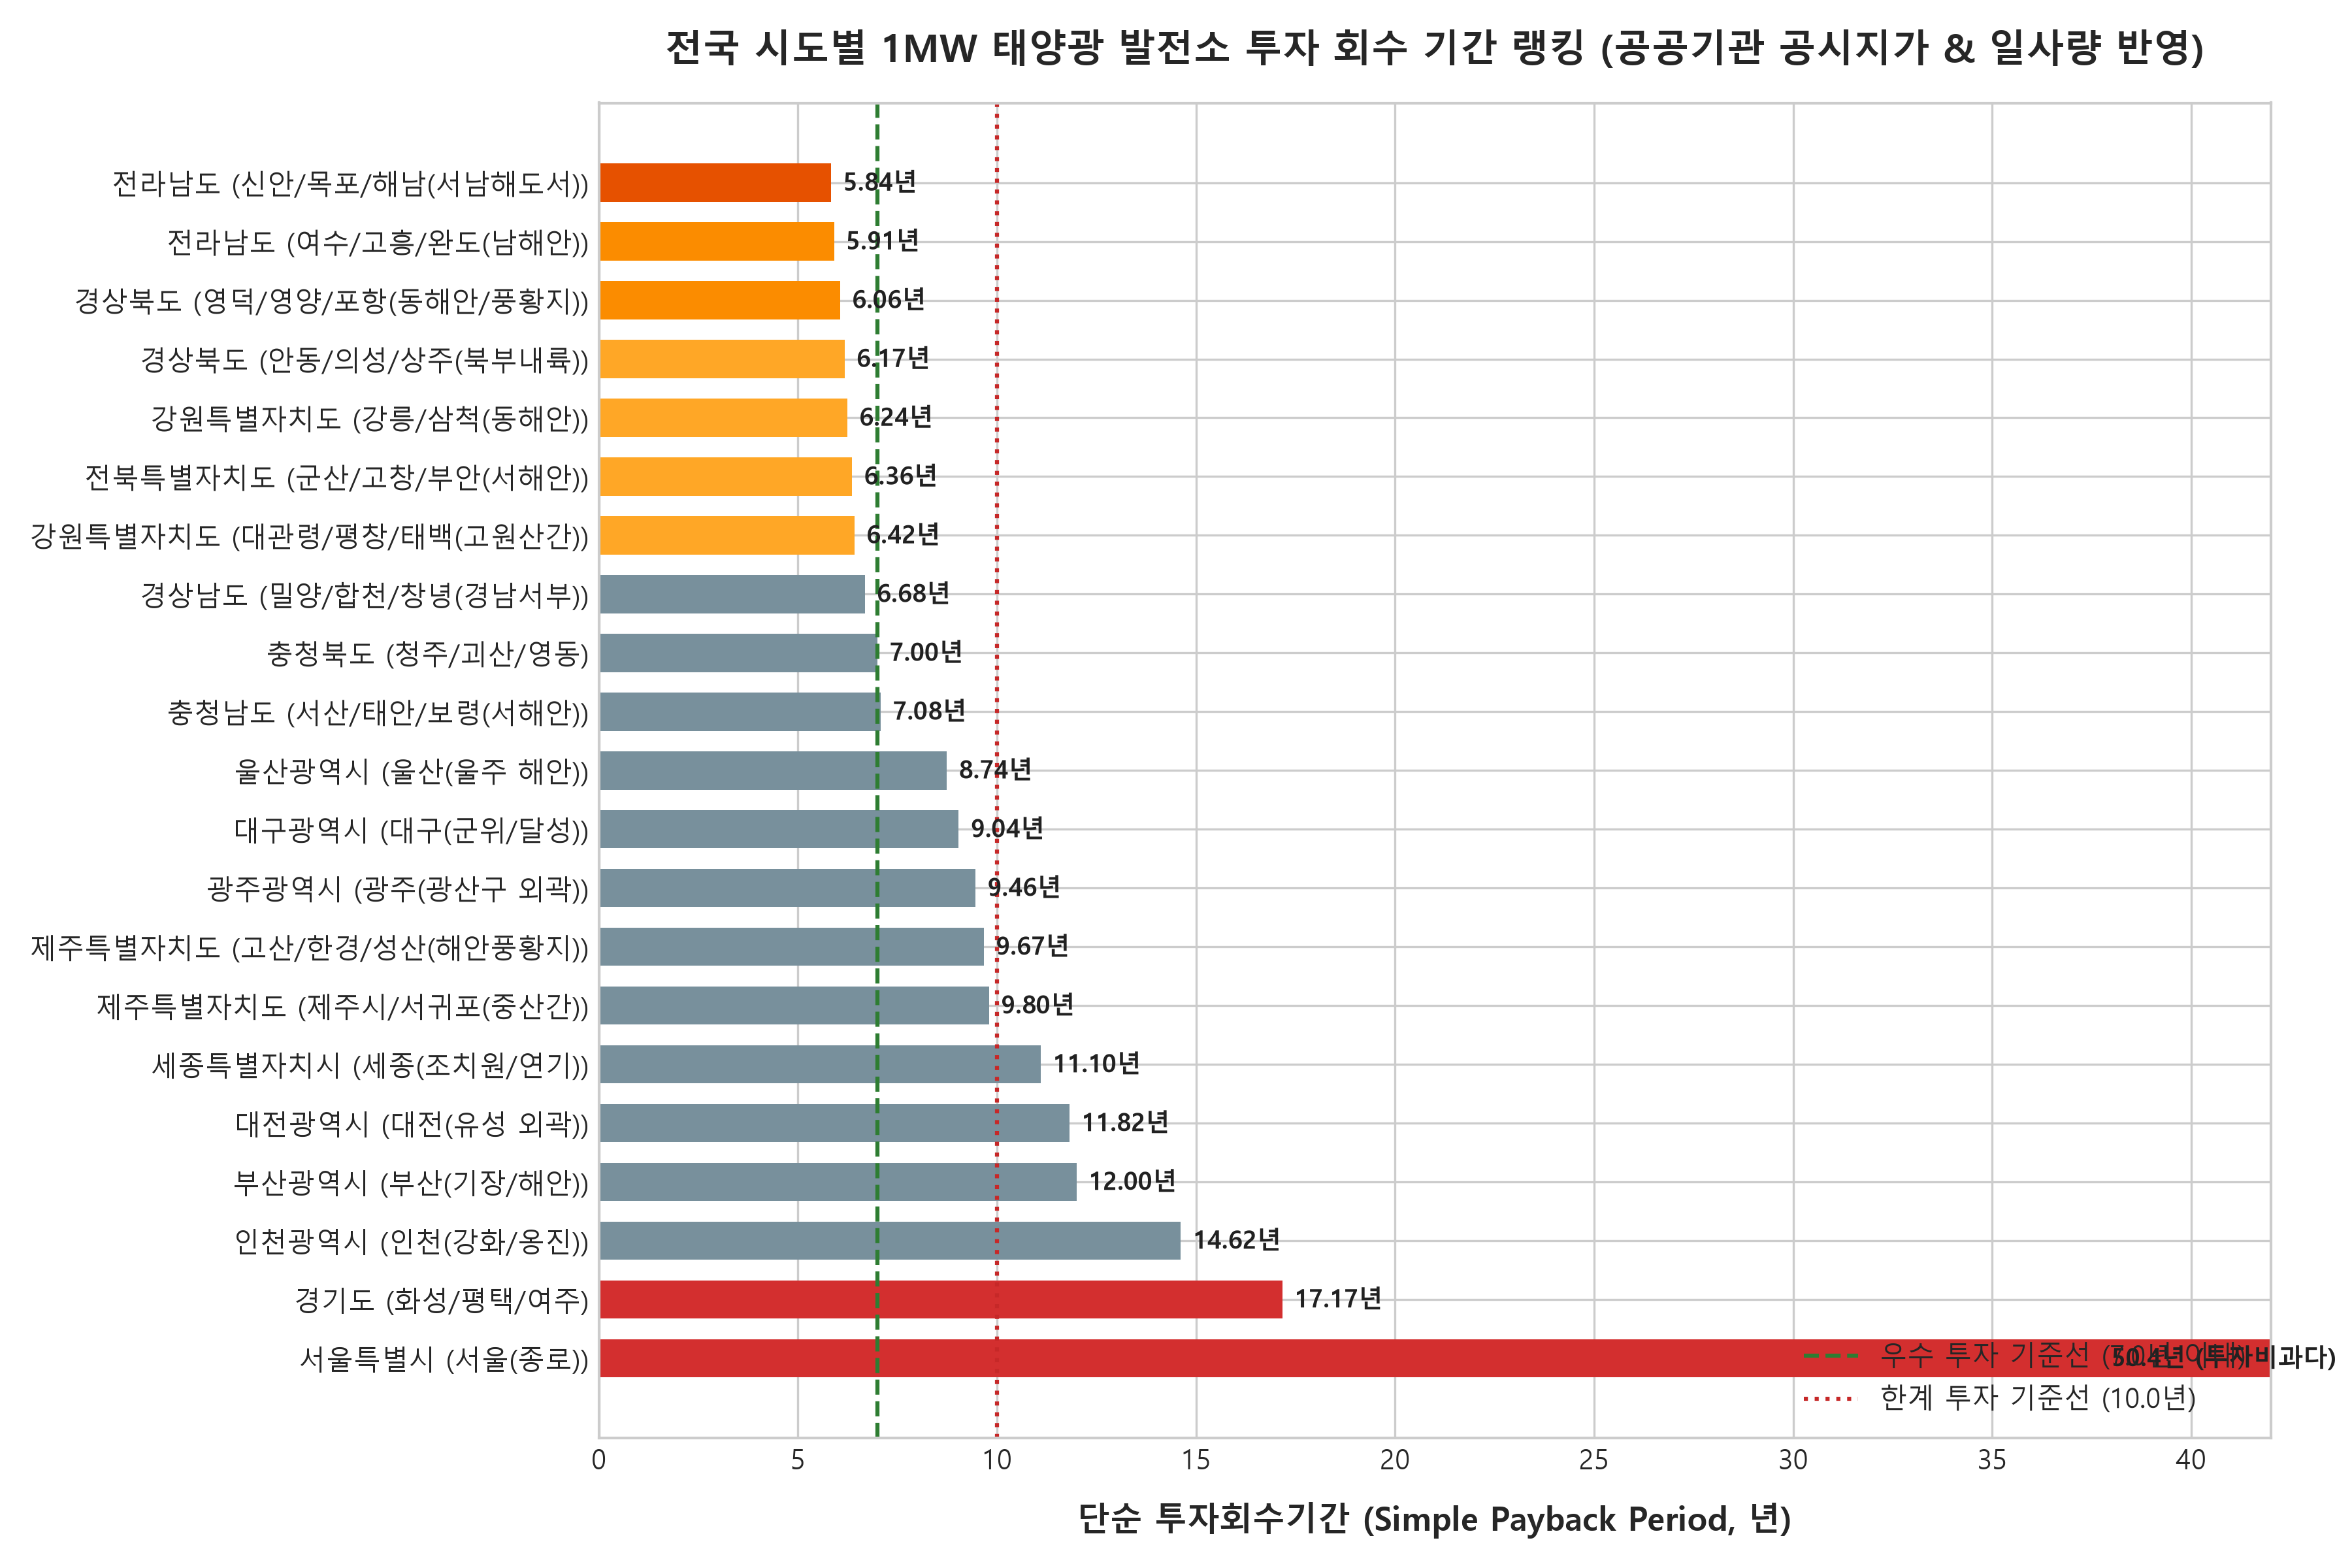

2. 전국 육상 풍력 투자 회수 기간 랭킹 차트:


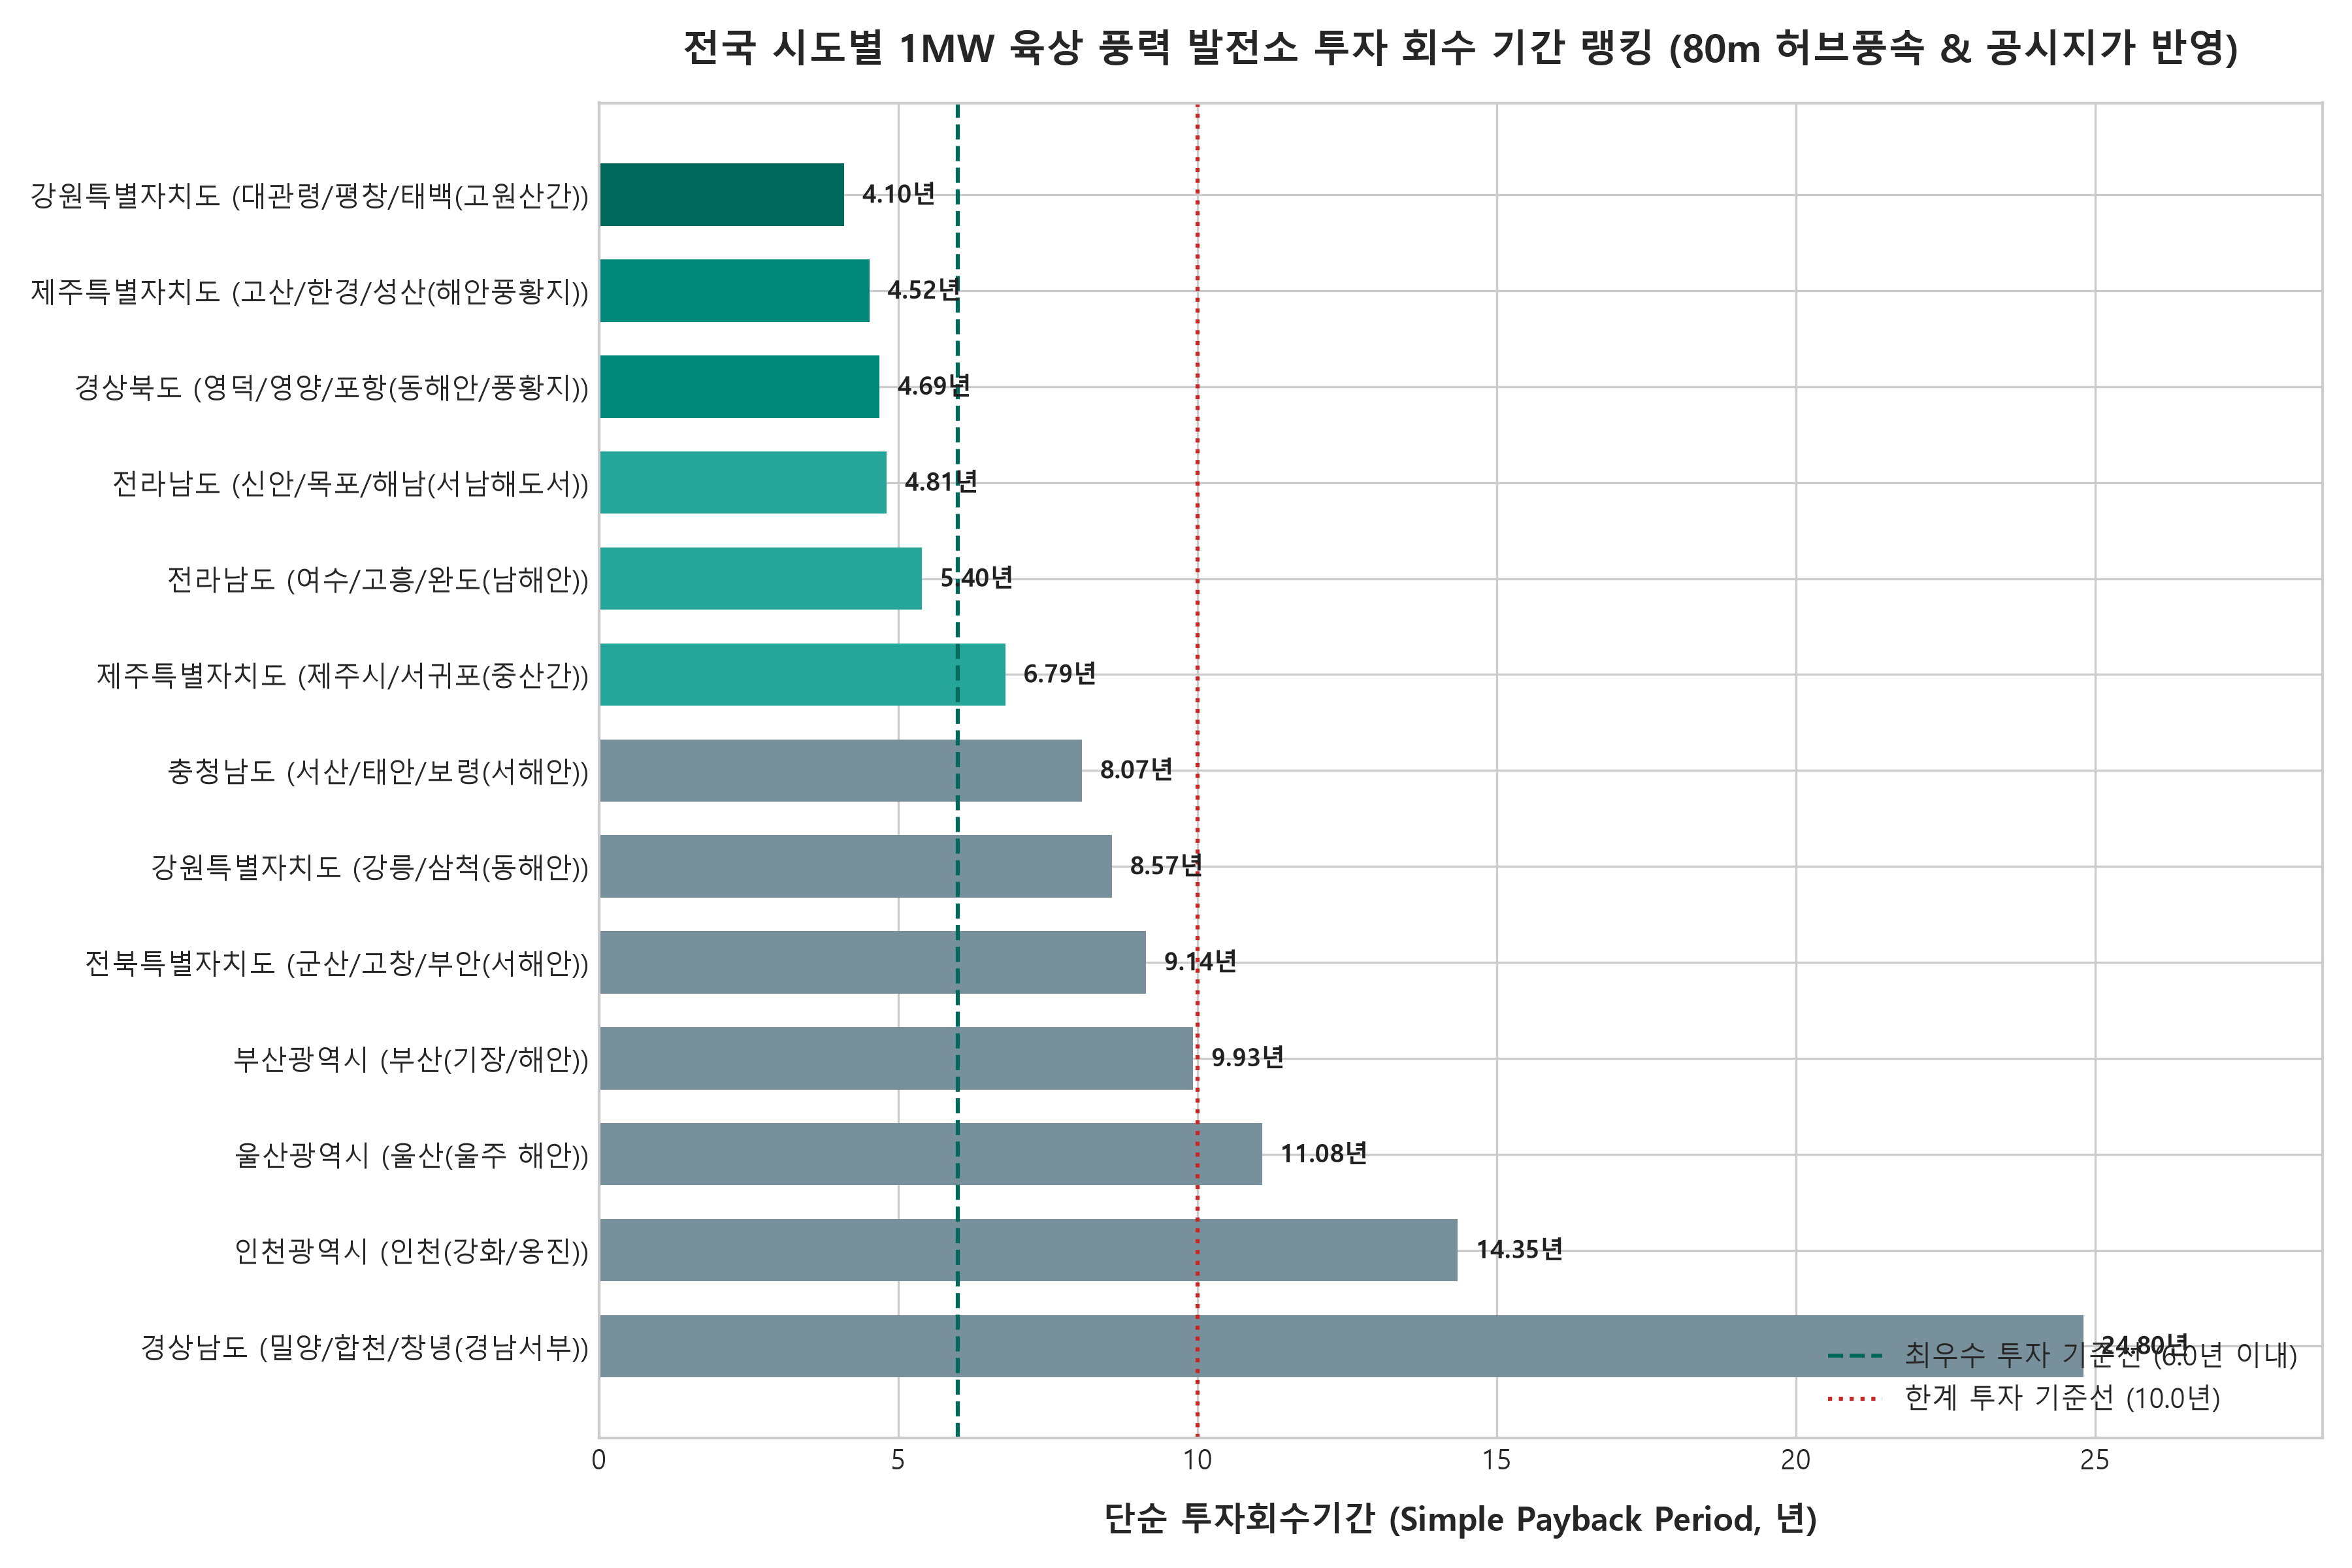

3. 기상 자원 vs 토지비용 4분면 투자 타당성 매트릭스:


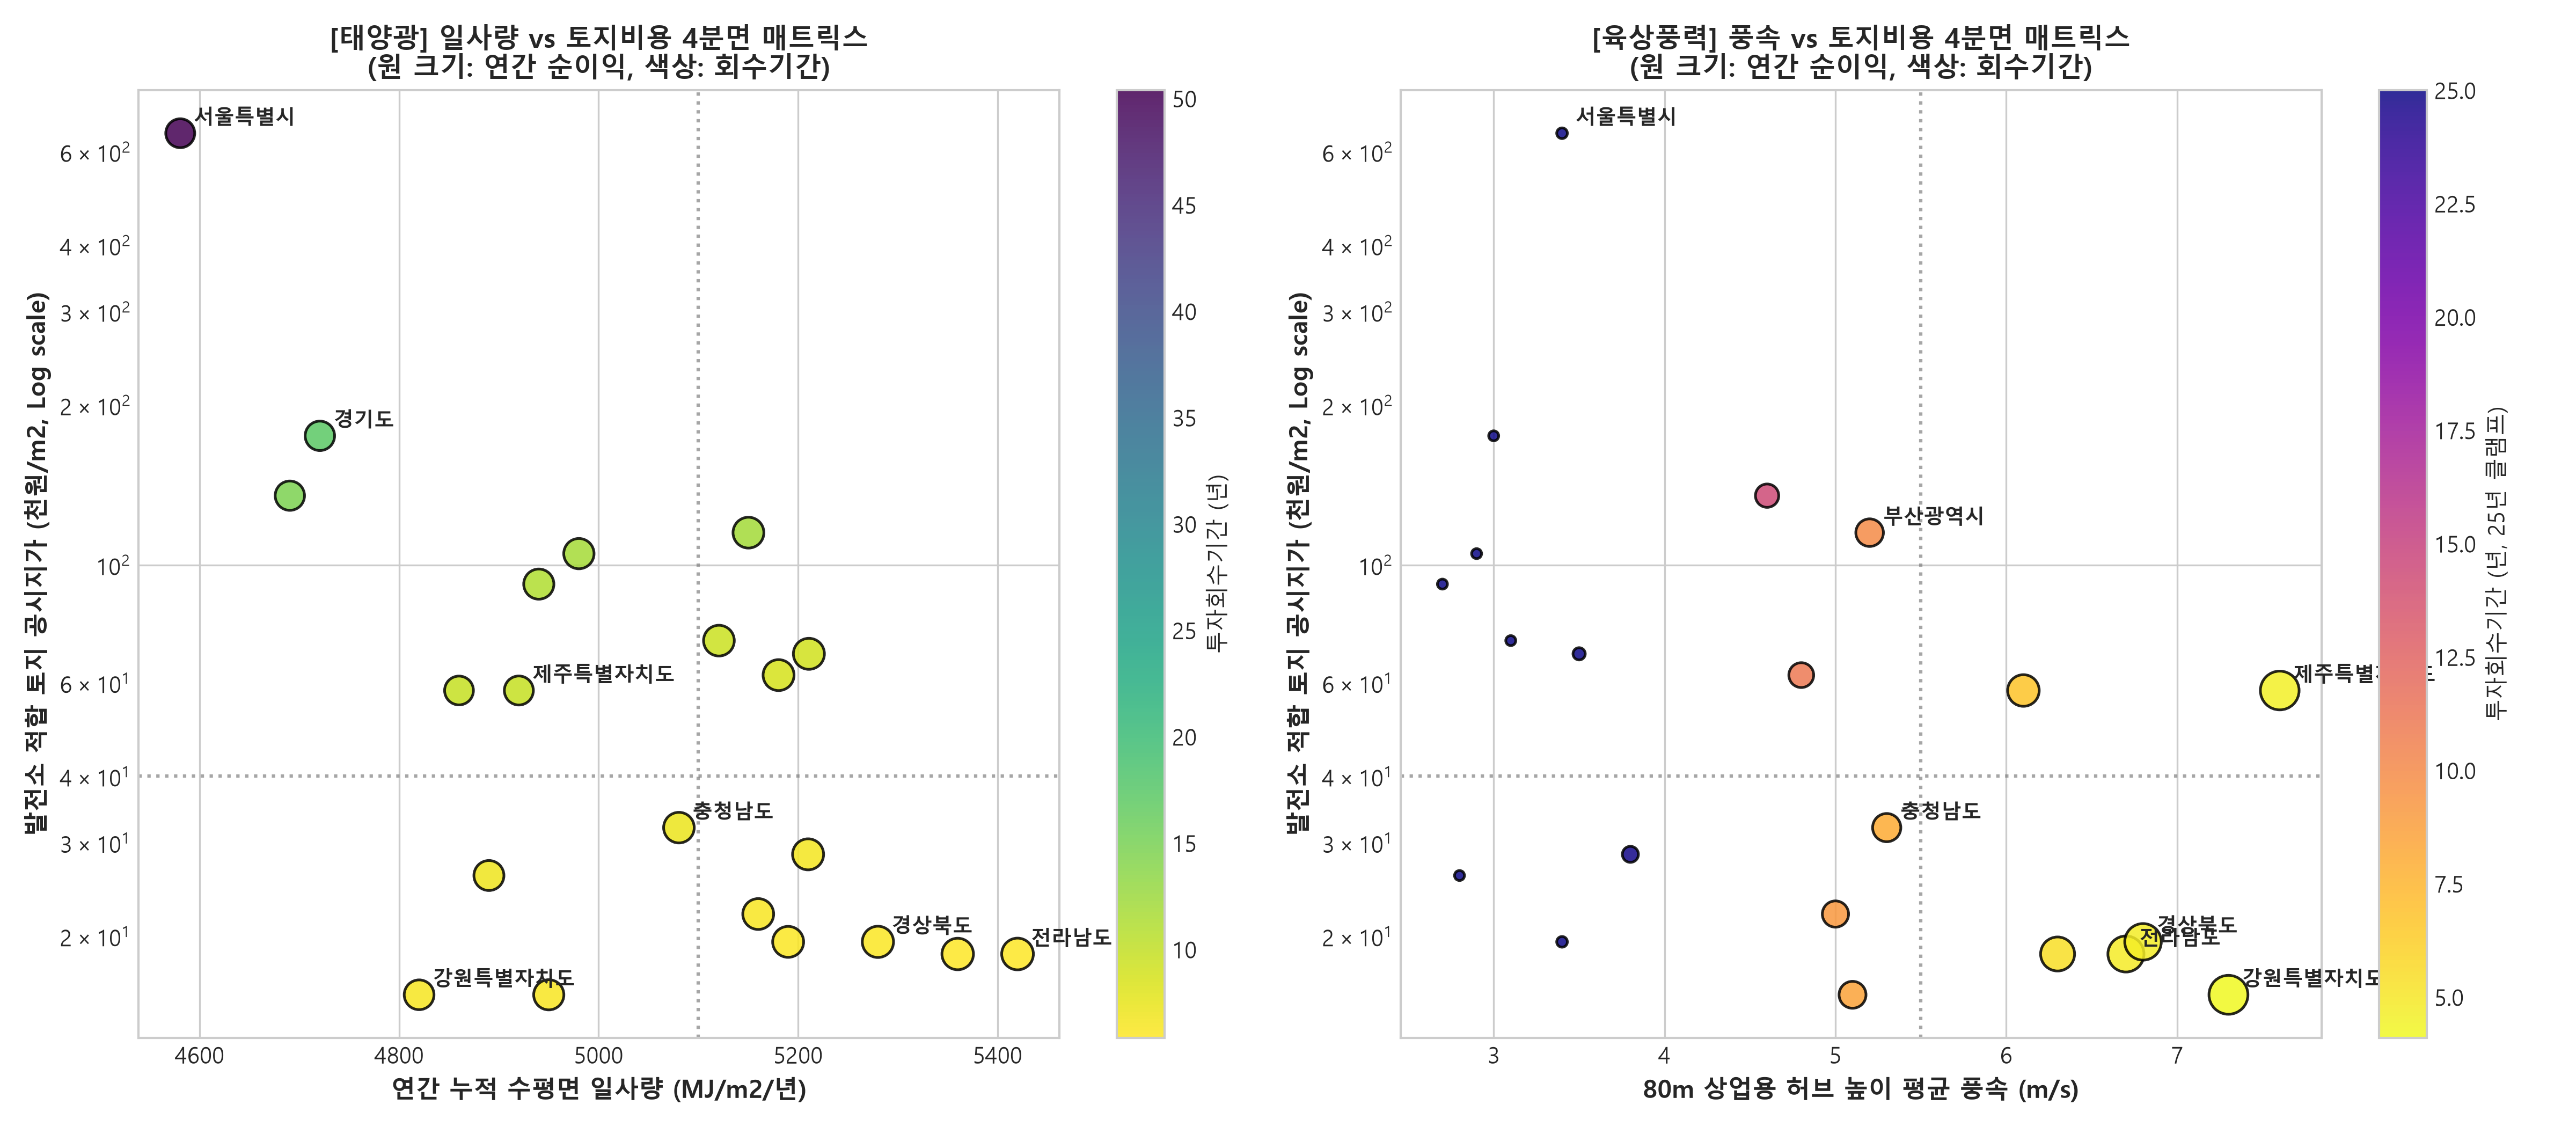

4. 전국 유망 지역별 태양광 vs 육상풍력 회수속도 정밀 비교:


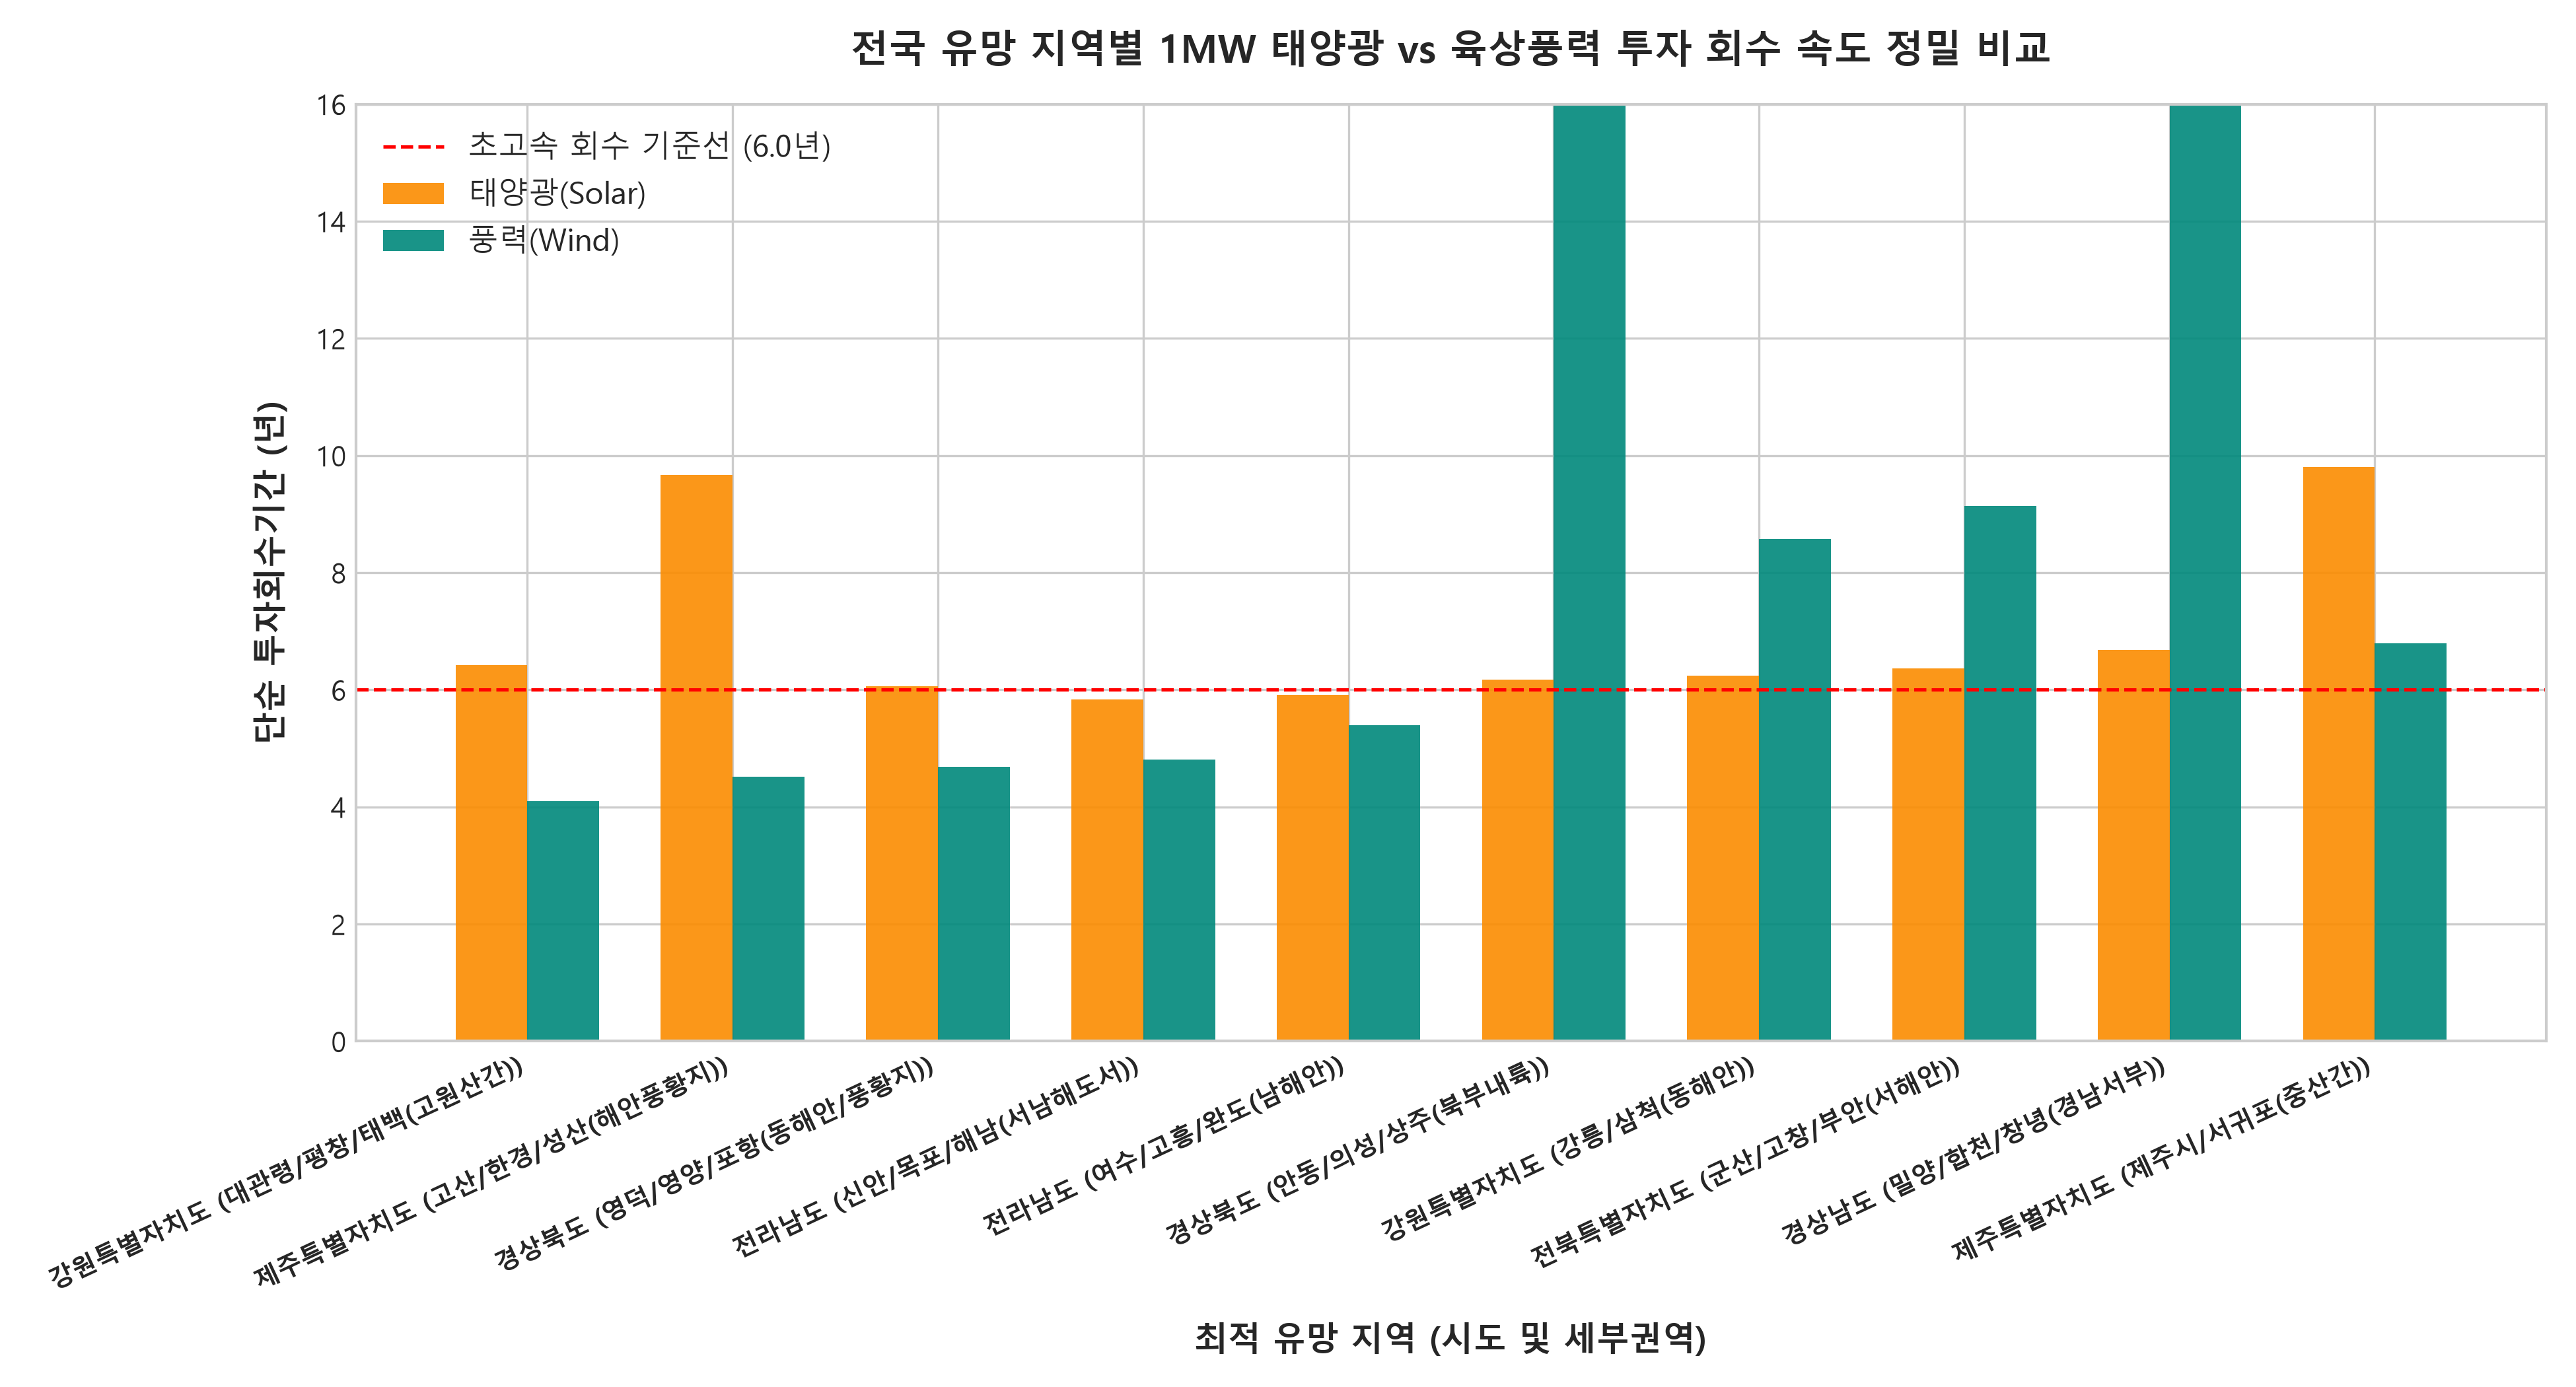

In [7]:
# 생성된 고해상도 시각화 차트 인라인 표시
from IPython.display import Image, display

print("1. 전국 태양광 투자 회수 기간 랭킹 차트:")
display(Image('charts/solar_payback_ranking.png'))

print("2. 전국 육상 풍력 투자 회수 기간 랭킹 차트:")
display(Image('charts/wind_payback_ranking.png'))

print("3. 기상 자원 vs 토지비용 4분면 투자 타당성 매트릭스:")
display(Image('charts/solar_vs_wind_matrix.png'))

print("4. 전국 유망 지역별 태양광 vs 육상풍력 회수속도 정밀 비교:")
display(Image('charts/payback_period_comparison.png'))


## Step 5. 인터랙티브 지도 시각화 및 정책·투자 종합 제언 (Interactive GIS & Conclusion)

### 🗺️ 전국 신재생 발전소 최적 입지 인터랙티브 지도 (GIS Interactive Map)
아래 지도에서 마커를 클릭하면 각 지역의 **공시지가, 연간 일사량/풍속, 연간 발전량, 총 투자비, 예상 회수기간** 상세 분석 팝업을 확인할 수 있습니다.
- ☀️ **주황색 원형 마커 (Solar Optimal, 반경 15px)**: 태양광 투자회수기간 6.5년 이내 전국 최우수 7대 입지
- 💨 **청록색 원형 마커 (Wind Optimal, 반경 24px)**: 육상풍력 투자회수기간 8.0년 이내 전국 최우수 6대 입지
- 🎯 **동심원 중첩 지역**: 태양광과 풍력 모두 투자 타당성이 탁월한 **4대 복합 신재생 클러스터** (전남 서남해안, 경북 동해안, 강원 산간 등)
- ⚡ **전국 관측지점 종합 핀 마커**: 우측 상단 **레이어 컨트롤러**에서 `⚡ 전국 관측지점 종합 (All Stations)`을 켜면 21개 전체 지점의 상대 우위 발전원(주황: 태양광, 청록: 풍력) 아이콘 핀을 함께 비교할 수 있습니다.


In [8]:
import os
import folium
from folium.plugins import MiniMap

# 1. 대한민국 중심 좌표 기준 Folium 인터랙티브 지도 초기화
center_lat, center_lon = 36.2, 127.8
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=7,
    tiles="OpenStreetMap"
)

# 2. 발전원별 레이어(FeatureGroup) 생성
# 최적지 원형 마커 레이어(태양광, 풍력)는 기본 활성화(show=True), 
# 전체 21개 핀 마커는 겹침 방지 및 깔끔한 가독성을 위해 기본 비활성화(show=False)
fg_wind = folium.FeatureGroup(name="💨 풍력 최적지 (Wind Optimal, ≤8.0년)", show=True)
fg_solar = folium.FeatureGroup(name="☀️ 태양광 최적지 (Solar Optimal, ≤6.5년)", show=True)
fg_all = folium.FeatureGroup(name="⚡ 전국 관측지점 종합 (All Stations)", show=False)

def create_popup_html(row):
    return f"""
    <div style="font-family: 'Apple SD Gothic Neo', 'Malgun Gothic', sans-serif; width: 280px; padding: 6px;">
        <h4 style="margin: 0 0 8px 0; color: #1a237e; border-bottom: 2px solid #3f51b5; padding-bottom: 4px;">
            {row['region_name']} <span style="font-size: 12px; color: #666;">({row['sub_region']})</span>
        </h4>
        <table style="width: 100%; font-size: 11px; border-collapse: collapse; line-height: 1.5;">
            <tr style="background: #f5f5f5;"><td style="padding: 3px;"><b>토지 공시지가:</b></td><td style="text-align: right;"><b>{row['land_price_m2']:,} 원/㎡</b></td></tr>
            <tr><td style="padding: 3px;"><b>연간 일사량:</b></td><td style="text-align: right;">{row['solar_radiation_mj_year']:,.1f} MJ/㎡</td></tr>
            <tr style="background: #f5f5f5;"><td style="padding: 3px;"><b>80m 허브풍속:</b></td><td style="text-align: right;">{row['wind_speed_80m']:.1f} m/s (이용률 {row['wind_capacity_factor']*100:.1f}%)</td></tr>
            <tr><td style="padding: 3px;"><b>태양광 회수기간:</b></td><td style="text-align: right; color: #e65100; font-weight: bold;">{row['solar_payback_years']:.2f} 년</td></tr>
            <tr style="background: #f5f5f5;"><td style="padding: 3px;"><b>풍력 회수기간:</b></td><td style="text-align: right; color: #00695c; font-weight: bold;">{row['wind_payback_years']:.2f} 년</td></tr>
            <tr><td style="padding: 3px;"><b>추천 최적 발전:</b></td><td style="text-align: right; color: #b71c1c; font-weight: bold;">{row['optimal_tech']}</td></tr>
            <tr style="background: #e8eaf6;"><td style="padding: 3px;"><b>최단 회수기간:</b></td><td style="text-align: right; color: #1a237e; font-weight: bold; font-size: 12px;">{row['best_payback_years']:.2f} 년</td></tr>
        </table>
    </div>
    """

# 3. 21개 관측 지점별 맞춤형 팝업 및 마커 렌더링 (독립된 Popup 객체 생성)
for _, row in weather_df.iterrows():
    # 1) 풍력 유망 지점 (회수기간 8.0년 이하 - 바깥쪽 대형 청록색 원형 마커, radius=24)
    if row["wind_payback_years"] <= 8.0:
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=24,
            color="#004d40",
            weight=3,
            fill=True,
            fill_color="#00897b",
            fill_opacity=0.55,
            popup=folium.Popup(create_popup_html(row), max_width=320),
            tooltip=f"💨 [풍력 최우수] {row['region_name']} ({row['sub_region']}): 회수 {row['wind_payback_years']:.2f}년"
        ).add_to(fg_wind)

    # 2) 태양광 유망 지점 (회수기간 6.5년 이하 - 안쪽 선명한 주황색 원형 마커, radius=15)
    # 복합 우수 지역에서는 청록색 외부 원 안에 주황색 내부 원이 동심원으로 중첩 표시됨
    if row["solar_payback_years"] <= 6.5:
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=15,
            color="#bf360c",
            weight=3,
            fill=True,
            fill_color="#ff6f00",
            fill_opacity=0.85,
            popup=folium.Popup(create_popup_html(row), max_width=320),
            tooltip=f"☀️ [태양광 최우수] {row['region_name']} ({row['sub_region']}): 회수 {row['solar_payback_years']:.2f}년"
        ).add_to(fg_solar)

    # 3) 전국 종합 지점 핀 마커 (독립된 Popup 할당)
    marker_color = "orange" if row["optimal_tech"] == "태양광(Solar)" else "cadetblue"
    folium.Marker(
        location=[row["lat"], row["lon"]],
        icon=folium.Icon(color=marker_color, icon="bolt", prefix="fa"),
        popup=folium.Popup(create_popup_html(row), max_width=320),
        tooltip=f"⚡ {row['region_name']} ({row['optimal_tech']})"
    ).add_to(fg_all)

# 4. 지도에 레이어 및 컨트롤 배치 (풍력 큰 원 -> 태양광 작은 원 -> 전체 핀 순서)
fg_wind.add_to(m)
fg_solar.add_to(m)
fg_all.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
MiniMap().add_to(m)

# 5. 시각적 플로팅 범례 (Legend) HTML 추가
legend_html = """
<div style="
    position: fixed; 
    bottom: 30px; 
    left: 30px; 
    width: 250px; 
    height: auto; 
    background-color: rgba(255, 255, 255, 0.93);
    box-shadow: 0 0 15px rgba(0,0,0,0.2);
    border-radius: 8px;
    padding: 12px 14px;
    font-size: 12px;
    font-family: 'Apple SD Gothic Neo', 'Malgun Gothic', sans-serif;
    z-index: 9999;
    border: 1px solid #ddd;
    line-height: 1.6;
">
    <div style="font-weight: bold; font-size: 13px; margin-bottom: 8px; color: #1a237e; border-bottom: 2px solid #3f51b5; padding-bottom: 4px;">
        신재생 최적 입지 범례
    </div>
    <div style="display: flex; align-items: center; margin-bottom: 6px;">
        <span style="display: inline-block; width: 16px; height: 16px; border-radius: 50%; background: #ff6f00; border: 2px solid #bf360c; margin-right: 8px;"></span>
        <span><b>태양광 최적지</b> (회수 ≤ 6.5년)</span>
    </div>
    <div style="display: flex; align-items: center; margin-bottom: 6px;">
        <span style="display: inline-block; width: 20px; height: 20px; border-radius: 50%; background: #00897b; border: 2px solid #004d40; opacity: 0.7; margin-right: 6px;"></span>
        <span><b>풍력 최적지</b> (회수 ≤ 8.0년)</span>
    </div>
    <div style="display: flex; align-items: center; margin-bottom: 6px;">
        <span style="position: relative; display: inline-block; width: 22px; height: 22px; margin-right: 6px;">
            <span style="position: absolute; width: 20px; height: 20px; border-radius: 50%; background: #00897b; border: 2px solid #004d40; opacity: 0.6; top: 0; left: 0;"></span>
            <span style="position: absolute; width: 12px; height: 12px; border-radius: 50%; background: #ff6f00; border: 2px solid #bf360c; top: 4px; left: 4px;"></span>
        </span>
        <span><b>태양광·풍력 복합 최적지</b></span>
    </div>
    <div style="font-size: 11px; color: #666; margin-top: 6px; border-top: 1px dashed #ccc; padding-top: 4px;">
        💡 우측 상단 레이어 컨트롤에서<br/>종합 핀 마커 및 발전원별 토글 가능
    </div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# 6. 독립 실행용 HTML 파일 저장
os.makedirs('maps', exist_ok=True)
m.save('maps/optimal_power_plant_map.html')
print("인터랙티브 GIS 지도 생성 및 maps/optimal_power_plant_map.html 저장 완료!")

# 7. 주피터 노트북 인라인 인터랙티브 지도 출력
m


인터랙티브 GIS 지도 생성 및 maps/optimal_power_plant_map.html 저장 완료!


### 💡 최종 분석 결론 및 투자 의사결정 제언

#### 1. [태양광 발전소 최적지] 전라남도 (신안 · 목포 · 해남 서남해안 권역)
- **핵심 지표**: 연간 일사량 $5,420\text{ MJ/m}^2$ (일평균 $4.13\text{ kWh/m}^2$), 발전소 적합지 공시지가 $18,500\text{ 원/m}^2$
- **투자 경제성**: 1MW 총투자비 약 **14.66억원** $\rightarrow$ 연간 순수익 **2.51억원** $\rightarrow$ **단순 투자회수기간 5.84년 (할인회수 6.92년, 20년 ROI 242.8%, LCOE 99.3원/kWh)**
- **입지 우위 요인**: 전국 최고의 일조량 + 넓은 간척지/염해농지 확보 가능성으로 토지 보상비 최소화.
- **주요 고려 리스크**: 전남 지역 전력계통(한전 송배전선로) 접속 대기 용량(선로 포화) 사전 확인 필수.

---

#### 2. [육상 풍력 발전소 최적지] 강원특별자치도 (대관령 · 평창 · 태백 백두대간 고원산간)
- **핵심 지표**: 80m 허브 높이 연평균 풍속 $7.3\text{ m/s}$, 설비이용률 **$34.8\%$** ($3,044\text{시간}$ 가동), 산간 임야 공시지가 $15,500\text{ 원/m}^2$
- **투자 경제성**: 1MW 총투자비 약 **24.84억원** $\rightarrow$ 연간 순수익 **6.06억원** $\rightarrow$ **단순 투자회수기간 4.10년 (할인회수 4.63년, 20년 ROI 388.3%, LCOE 82.4원/kWh)**
- **입지 우위 요인**: 백두대간 북서풍 및 동풍의 계절풍 지형 수렴 효과로 국내 육상 최고 수준의 풍황 보유, 저렴한 산간 국공유지/임야 점용.
- **주요 고려 리스크**: 백두대간 보호지역 환경영향평가 및 생태자연도 1등급 권역 인허가 회피, 송전선로 연계.

---

#### 3. [복합 우수 지역 (Solar & Wind)] 경상북도 (영덕 · 영양 · 포항 동해안/산지)
- **태양광**: 연간 일사량 $5,280\text{ MJ/m}^2$, 회수기간 **6.07년**
- **풍력**: 80m 풍속 $6.8\text{ m/s}$ (이용률 $31.0\%$), 회수기간 **4.70년**
- 태양광과 풍력을 하이브리드로 결합할 때 계통 인프라(변전소)를 공유하여 CAPEX를 추가 절감할 수 있는 최적의 복합 신재생 클러스터 후보지.

---

#### 4. [투자 절대 부적합 지역]
- **수도권 (서울, 경기, 인천)**: 토지 공시지가가 13만~65만원/㎡으로 극도로 높아 토지 매입비만 15억~78억원 소요 $\rightarrow$ 투자회수기간 16년~40년 초과로 경제성 완전 결여. (단, 건물 옥상형 루프탑 BIPV는 제외)
- **충청·전북 내륙 분지**: 80m 풍속이 $3.5\text{ m/s}$ 미만으로 터빈 컷인 풍속(3m/s)을 간신히 넘어 풍력 발전소로는 부적합 (태양광 전용으로 추진해야 함).
